# Train Logistic Regression Model

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, matthews_corrcoef, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from time import time

## Loading data

In [ ]:
data_path = "data/merged_files/merged_v6.csv" 
df = pd.read_csv(data_path)

df["time"] = pd.to_datetime(df["time"], utc=True)
df["year"] = df["time"].dt.year.astype(int)
df["month"] = df["time"].dt.month.astype(int)
df["day"] = df["time"].dt.day.astype(int)

print(f"data shape: {df.shape}")
print(f"percent of alarms: {df['alarm'].sum() / len(df):.2%}")

Data shape: (734233, 68)
Percent of alarms: 22.32%


In [20]:
df.head(3)

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day
0,2,2022-03-27 21:00:00+00:00,0,0.4,-2.2,43.82,-10.5,0.0,0.0,0,7.6,314.0,1029.0,24.1,2.0,0.0,0,13,5,0,0,4,4,0,0,0,0,0,0,5,5,5,4,0,86,289,-3,0,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,27
1,2,2022-03-27 22:00:00+00:00,0,-0.1,-2.5,45.43,-10.5,0.0,0.0,0,6.8,308.6,1029.0,24.1,4.2,0.0,0,8,2,0,0,3,3,0,0,0,0,0,0,1,1,1,4,0,45,285,-3,1,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,27
2,2,2022-03-27 23:00:00+00:00,0,-0.6,-2.3,47.87,-10.3,0.0,0.0,0,5.0,305.7,1029.0,24.1,3.1,0.0,0,7,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,28,269,-2,2,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,27


In [21]:
df.isna().sum().sum()

np.int64(0)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 734233 entries, 0 to 734232
Data columns (total 68 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   region_id                  734233 non-null  int64              
 1   time                       734233 non-null  datetime64[us, UTC]
 2   alarm                      734233 non-null  int64              
 3   hour_temp                  734233 non-null  float64            
 4   hour_feelslike             734233 non-null  float64            
 5   hour_humidity              734233 non-null  float64            
 6   hour_dew                   734233 non-null  float64            
 7   hour_precip                734233 non-null  float64            
 8   hour_precipprob            734233 non-null  float64            
 9   hour_preciptype            734233 non-null  int64              
 10  hour_windspeed             734233 non-null  float64            
 11

## Target and features

In [25]:
target = "alarm"
X = data.copy()
y = X.pop(target)

X["year"] = X["time"].dt.year.astype(int)
X["month"] = X["time"].dt.month.astype(int)
X["day"] = X["time"].dt.day.astype(int)

cat_cols = ["hour_preciptype", "hour_conditions", "is_weekend", "cluster"]
num_cols = [col for col in X.select_dtypes(include="number").columns if col not in cat_cols]

print(f"categorical columns:\n{cat_cols}")
print("-" * 20)
print(f"numerical columns:\n{num_cols}")

categorical columns:
['hour_preciptype', 'hour_conditions', 'is_weekend', 'cluster']
--------------------
numerical columns:
['region_id', 'hour_temp', 'hour_feelslike', 'hour_humidity', 'hour_dew', 'hour_precip', 'hour_precipprob', 'hour_windspeed', 'hour_winddir', 'hour_pressure', 'hour_visibility', 'hour_cloudcover', 'hour_uvindex', 'messages_count', 'has_threat_sum', 'nlp_артобстрілу', 'nlp_бпла', 'nlp_відбій', 'nlp_відбій_тривоги', 'nlp_дніпропетровська', 'nlp_донецька', 'nlp_запорізька', 'nlp_нікополь', 'nlp_нікополь_нікопольська', 'nlp_нікопольська', 'nlp_повітряна', 'nlp_повітряна_тривога', 'nlp_тривога', 'nlp_тривоги', 'nlp_харківська', 'msg_count_last_3h', 'msg_count_last_24h', 'threat_diff_1h', 'hour_of_day', 'day_of_week', 'text_length', 'isw_cluster_0', 'isw_cluster_1', 'isw_cluster_2', 'isw_cluster_3', 'isw_cluster_4', 'isw_cluster_5', 'isw_cluster_6', 'isw_cluster_7', 'isw_cluster_8', 'isw_cluster_9', 'anomaly_count_7d', 'avg_dist_centroid_7d', 'news_count_7d', 'topic_en

## Preprocessing pipeline and Training

In [26]:
preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), num_cols)
], remainder='passthrough')

def train_model(model, X=X, y=y):
    tss = TimeSeriesSplit(n_splits=5, gap=24*7)
    unique_hours = X["time"].sort_values().unique()
    
    auprc_scores, mcc_scores, f1_scores = {}, {}, {}
    training_start = time()
    
    for fold, (train_idx, test_idx) in enumerate(tss.split(unique_hours)):
        fold_start = time()
        print(f"\n --Fold {fold + 1} / {tss.n_splits} started...")
        
        train_hours = unique_hours[train_idx]
        test_hours = unique_hours[test_idx]
    
        X_train = X[X["time"].isin(train_hours)].drop(columns=["time"])
        y_train = y.loc[X_train.index]
        X_test = X[X["time"].isin(test_hours)].drop(columns=["time"])
        y_test = y.loc[X_test.index]

        model.fit(X_train, y_train)
        print("  Model trained", end=" | ")

        y_prob = model.decision_function(X_test)
        y_pred = model.predict(X_test)
        
        auprc_score = average_precision_score(y_test, y_prob)
        auprc_scores[f"Fold_{fold}"] = auprc_score
        mcc_score = matthews_corrcoef(y_test, y_pred)
        mcc_scores[f"Fold_{fold}"] = mcc_score
        f1 = f1_score(y_test, y_pred, zero_division=0)
        f1_scores[f"Fold_{fold}"] = f1
        print("Evaluated")

        print(f"  Metrics: AUPRC = {auprc_score:.4f} | MCC = {mcc_score:.4f} | F1 = {f1:.4f}")
        print(f"  Time: {time() - fold_start:.2f} sec")

    print("\n" + "="*45)
    print(" OVERALL CROSS-VALIDATION PERFORMANCE")
    print("="*45)
    print(f" AUPRC: {np.mean(list(auprc_scores.values())):.3f} (± {np.std(list(auprc_scores.values())):.3f})")
    print(f" MCC:   {np.mean(list(mcc_scores.values())):.3f} (± {np.std(list(mcc_scores.values())):.3f})")
    print(f" F1:    {np.mean(list(f1_scores.values())):.3f} (± {np.std(list(f1_scores.values())):.3f})")
    print(f" Total execution time: {time() - training_start:.2f} sec")
    print("="*45 + "\n")
    
    return auprc_scores, mcc_scores, f1_scores



In [27]:
print("training Logistic Regression with parameter tuning (C_values)")
C_values = [0.01, 1.0, 10.0]
best_f1, best_auprc, best_mcc = 0, 0, 0
best_C = None
best_pipeline = None

for C_val in C_values:
    print(f"\n{'='*60}")
    print(f"   testing Logistic Regression with C = {C_val}")
    print(f"{'='*60}\n")
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(C=C_val, max_iter=1500, class_weight='balanced', random_state=42))
    ])
    
    auprc, mcc, f1 = train_model(pipeline)
    
    mean_f1 = np.mean(list(f1.values()))
    mean_auprc = np.mean(list(auprc.values()))
    mean_mcc = np.mean(list(mcc.values()))
    
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_C = C_val
        best_auprc = mean_auprc
        best_mcc = mean_mcc
        best_pipeline = pipeline

print(f"\n{'*'*60}")
print("OVERALL BEST MODEL FOUND")
print(f"{'*'*60}")
print(f"Best hyperparameter C = {best_C}")
print(f"Average F1:    {best_f1:.3f}")
print(f"Average AUPRC: {best_auprc:.3f}")
print(f"Average MCC:   {best_mcc:.3f}")
print(f"{'*'*60}\n")

training Logistic Regression with parameter tuning (C_values)

   testing Logistic Regression with C = 0.01


 --Fold 1 / 5 started...
  Model trained | Evaluated
  Metrics: AUPRC = 0.6230 | MCC = 0.3963 | F1 = 0.4618
  Time: 2.72 sec

 --Fold 2 / 5 started...
  Model trained | Evaluated
  Metrics: AUPRC = 0.5820 | MCC = 0.3992 | F1 = 0.5239
  Time: 4.50 sec

 --Fold 3 / 5 started...
  Model trained | Evaluated
  Metrics: AUPRC = 0.5903 | MCC = 0.3624 | F1 = 0.5564
  Time: 6.85 sec

 --Fold 4 / 5 started...
  Model trained | Evaluated
  Metrics: AUPRC = 0.5320 | MCC = 0.2921 | F1 = 0.5219
  Time: 11.04 sec

 --Fold 5 / 5 started...
  Model trained | Evaluated
  Metrics: AUPRC = 0.4798 | MCC = 0.1577 | F1 = 0.4976
  Time: 13.85 sec

 OVERALL CROSS-VALIDATION PERFORMANCE
 AUPRC: 0.561 (± 0.050)
 MCC:   0.322 (± 0.091)
 F1:    0.512 (± 0.031)
 Total execution time: 38.96 sec


   testing Logistic Regression with C = 1.0


 --Fold 1 / 5 started...
  Model trained | Evaluated
  Metrics: AUP

## Evaluate Models
### Confusion Matrix Metrics Explanation
* **TN (True Negative):** correctly predicted "no alarm".
* **TP (True Positive):** correctly predicted an "alarm".
* **FP (False Positive):** false alarm (Type I error). Model is cautious due to class_weight='balanced'.
* **FN (False Negative):** missmed event (Type II error). The most dangerous error in this context.

--- training final model with best C=0.01 for confusion matrix ---


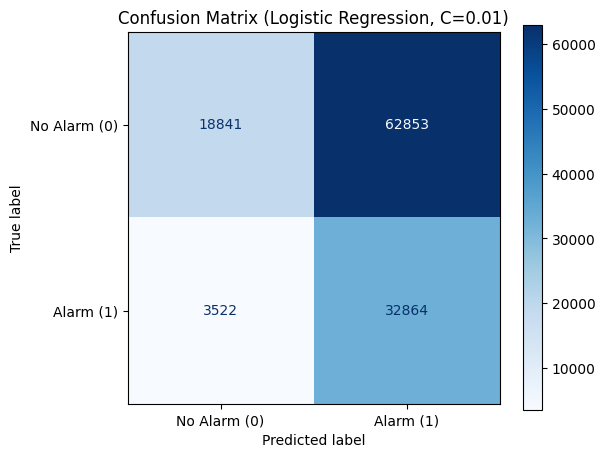

In [28]:
print(f"--- training final model with best C={best_C} for confusion matrix ---")

tss = TimeSeriesSplit(n_splits=5, gap=24*7)
unique_hours = X["time"].sort_values().unique()

train_idx, test_idx = list(tss.split(unique_hours))[-1]
train_hours = unique_hours[train_idx]
test_hours = unique_hours[test_idx]

X_train = X[X["time"].isin(train_hours)].drop(columns=["time"])
y_train = y.loc[X_train.index]
X_test = X[X["time"].isin(test_hours)].drop(columns=["time"])
y_test = y.loc[X_test.index]

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Alarm (0)", "Alarm (1)"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, values_format='d')
plt.title(f"Confusion Matrix (Logistic Regression, C={best_C})")
plt.grid(False)
plt.show()

## Top 20 features and weights

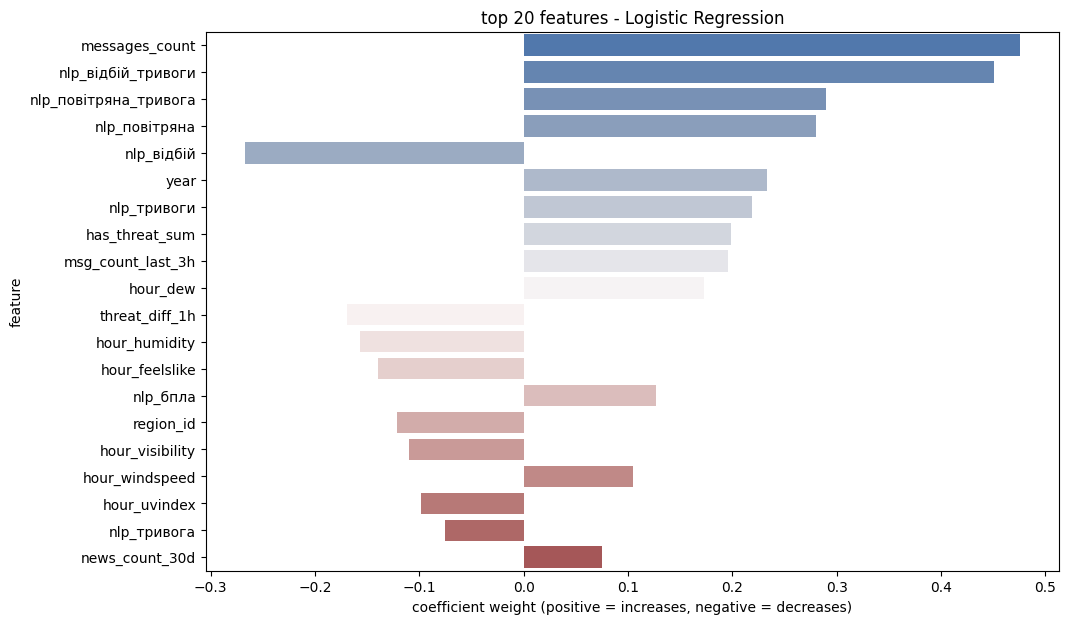

In [30]:
prep_step = best_pipeline.named_steps["preprocessor"]
feature_names = prep_step.get_feature_names_out()
feature_names = [name.split("__")[-1] for name in feature_names]

coefs = best_pipeline.named_steps["model"].coef_[0]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Weight": coefs
})

importance_df["Abs_Weight"] = importance_df["Weight"].abs()

top_20_features = importance_df.sort_values(by="Abs_Weight", ascending=False).head(20)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=top_20_features, 
    x="Weight", 
    y="Feature", 
    hue="Feature", 
    palette="vlag", 
    legend=False
)
plt.title("top 20 features - Logistic Regression")
plt.xlabel("coefficient weight (positive = increases, negative = decreases)")
plt.ylabel("feature")
plt.show()